# Business Insights and Marketing Recommendations
## Customer Personality Analysis Dataset

**Module 08 — Machine Learning**

This notebook transforms the customer segments from Module 07 into practical
marketing and business strategies: personas, business opportunities,
marketing/product/pricing/retention/reactivation strategies, a campaign
action plan, a strategy matrix, and a business insights dashboard.


In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
%matplotlib inline

df = pd.read_csv("00_Data/customer_profiles_final.csv")

SPEND_COLS = ["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
CAMPAIGN_COLS = ["AcceptedCmp1","AcceptedCmp2","AcceptedCmp3","AcceptedCmp4","AcceptedCmp5","Response"]
SEGMENT_COLORS = {
    "High-Value Customers": "#C44E52",
    "Premium / Loyal Buyers": "#4C72B0",
    "Discount Seekers / Budget Customers": "#8172B2",
    "New / Developing Customers": "#55A868",
}
df["Segment_Name"].value_counts()

Segment_Name
New / Developing Customers             676
Premium / Loyal Buyers                 639
High-Value Customers                   495
Discount Seekers / Budget Customers    427
Name: count, dtype: int64

## Task 1 — Review Customer Segments

In [2]:
counts = df["Segment_Name"].value_counts()
summary = pd.DataFrame({
    "Cluster": [df.loc[df["Segment_Name"]==s, "Cluster"].iloc[0] for s in counts.index],
    "Business Name": counts.index,
    "Customers": counts.values,
    "Percentage": (counts.values/len(df)*100).round(1),
}).sort_values("Cluster").reset_index(drop=True)
summary

,Cluster,Business Name,Customers,Percentage
0,0,Discount Seekers / Budget Customers,427,19.1
1,1,Premium / Loyal Buyers,639,28.6
2,2,New / Developing Customers,676,30.2
3,3,High-Value Customers,495,22.1


### Segment Metrics (used throughout this notebook)

In [3]:
metrics = df.groupby("Segment_Name").agg(
    Customers=("Segment_Name","count"), Avg_Income=("Income","mean"),
    Avg_Total_Spending=("Total_Spending","mean"), Avg_Purchases=("Total_Purchases","mean"),
    Avg_Recency=("Recency","mean"), Deal_Dependency=("Deal_Dependency","mean"),
    Campaign_Response_Rate=("Response","mean"), Complaint_Rate=("Complain","mean"),
).round(2)
metrics["Revenue_Contribution"] = df.groupby("Segment_Name")["Total_Spending"].sum()
metrics["Revenue_Share_Pct"] = (metrics["Revenue_Contribution"]/metrics["Revenue_Contribution"].sum()*100).round(1)

r_norm = (metrics["Avg_Recency"]-metrics["Avg_Recency"].min())/(metrics["Avg_Recency"].max()-metrics["Avg_Recency"].min()+1e-9)
resp_norm = 1-(metrics["Campaign_Response_Rate"]-metrics["Campaign_Response_Rate"].min())/(metrics["Campaign_Response_Rate"].max()-metrics["Campaign_Response_Rate"].min()+1e-9)
freq_norm = 1-(metrics["Avg_Purchases"]-metrics["Avg_Purchases"].min())/(metrics["Avg_Purchases"].max()-metrics["Avg_Purchases"].min()+1e-9)
metrics["Churn_Risk_Score"] = (r_norm*0.4 + resp_norm*0.3 + freq_norm*0.3).round(3)
metrics["Churn_Risk_Level"] = pd.cut(metrics["Churn_Risk_Score"], bins=[-0.01,0.33,0.66,1.01], labels=["Low","Medium","High"])
metrics["Top_Product_Category"] = df.groupby("Segment_Name")[SPEND_COLS].mean().idxmax(axis=1).str.replace("Mnt","")
metrics["Estimated_CLV_3yr"] = (metrics["Avg_Total_Spending"]*3).round(0)
metrics = metrics.reset_index()
metrics

,Segment_Name,Customers,Avg_Income,Avg_Total_Spending,Avg_Purchases,Avg_Recency,Deal_Dependency,Campaign_Response_Rate,Complaint_Rate,Revenue_Contribution,Revenue_Share_Pct,Churn_Risk_Score,Churn_Risk_Level,Top_Product_Category,Estimated_CLV_3yr
0,Discount Seekers / Budget Customers,427,42574.21,131.33,9.43,50.18,0.29,0.07,0.01,56076,4.1,0.963,High,Wines,394.0
1,High-Value Customers,495,76704.96,1430.10,20.47,50.07,0.06,0.35,0.00,707900,52.2,0.410,Medium,Wines,4290.0
2,New / Developing Customers,676,31890.56,104.90,7.68,49.02,0.22,0.10,0.01,70913,5.2,0.778,High,Wines,315.0
3,Premium / Loyal Buyers,639,59926.54,814.02,21.78,47.73,0.16,0.10,0.01,520159,38.4,0.268,Low,Wines,2442.0


## Task 2 — Develop Customer Personas

In [4]:
for _, row in metrics.iterrows():
    print(f"=== {row['Segment_Name']} ===")
    print(f"  Income: {'High' if row['Avg_Income']>metrics['Avg_Income'].median() else 'Low-Medium'} (${row['Avg_Income']:,.0f})")
    print(f"  Spending: ${row['Avg_Total_Spending']:,.0f} | Purchases: {row['Avg_Purchases']:.1f}")
    print(f"  Top product: {row['Top_Product_Category']} | Campaign response: {row['Campaign_Response_Rate']*100:.1f}%")
    print(f"  Deal dependency: {row['Deal_Dependency']*100:.1f}% | Risk: {row['Churn_Risk_Level']}")
    print(f"  Estimated 3yr CLV: ${row['Estimated_CLV_3yr']:,.0f}")
    print()

=== Discount Seekers / Budget Customers ===
  Income: Low-Medium ($42,574)
  Spending: $131 | Purchases: 9.4
  Top product: Wines | Campaign response: 7.0%
  Deal dependency: 29.0% | Risk: High
  Estimated 3yr CLV: $394

=== High-Value Customers ===
  Income: High ($76,705)
  Spending: $1,430 | Purchases: 20.5
  Top product: Wines | Campaign response: 35.0%
  Deal dependency: 6.0% | Risk: Medium
  Estimated 3yr CLV: $4,290

=== New / Developing Customers ===
  Income: Low-Medium ($31,891)
  Spending: $105 | Purchases: 7.7
  Top product: Wines | Campaign response: 10.0%
  Deal dependency: 22.0% | Risk: High
  Estimated 3yr CLV: $315

=== Premium / Loyal Buyers ===
  Income: High ($59,927)
  Spending: $814 | Purchases: 21.8
  Top product: Wines | Campaign response: 10.0%
  Deal dependency: 16.0% | Risk: Low
  Estimated 3yr CLV: $2,442



## Task 3 — Analyze Business Opportunities

| Segment | Value | Opportunity | Risk |
|---|---|---|---|
| High-Value | Highest spend & revenue share (52.2%) | Upsell premium lines, grow share-of-wallet | Campaign fatigue; high revenue-loss impact if churned |
| Premium/Loyal | Most active across all channels | Cross-sell across channels already used | Under-targeted relative to engagement |
| Discount Seekers | Large, stable transaction base | Family-size bundles lift basket size | Lowest campaign response — highest disengagement risk |
| New/Developing | Largest segment by count (30.2%) | Nurture into higher-value segments | May never develop without intervention |


## Task 4 — Marketing Strategy Design

In [5]:
strategy = pd.DataFrame([
    {"Segment":"High-Value Customers","Message":"Exclusive access to our Premium Collection","Channel":"Email + Personal outreach","Frequency":"Monthly"},
    {"Segment":"Premium / Loyal Buyers","Message":"More of what you love, everywhere you shop","Channel":"Email + App/Web push","Frequency":"Bi-weekly"},
    {"Segment":"Discount Seekers / Budget Customers","Message":"Save more on family favorites","Channel":"SMS + Email","Frequency":"Bi-weekly"},
    {"Segment":"New / Developing Customers","Message":"Welcome! Explore what's possible","Channel":"Email + SMS onboarding","Frequency":"Weekly then monthly"},
])
strategy

,Segment,Message,Channel,Frequency
0,High-Value Customers,Exclusive access to our Premium Collection,Email + Personal outreach,Monthly
1,Premium / Loyal Buyers,"More of what you love, everywhere you shop",Email + App/Web push,Bi-weekly
2,Discount Seekers / Budget Customers,Save more on family favorites,SMS + Email,Bi-weekly
3,New / Developing Customers,Welcome! Explore what's possible,Email + SMS onboarding,Weekly then monthly


## Task 5 — Product Recommendation Strategy

In [6]:
rows = []
for _, row in metrics.iterrows():
    seg = row["Segment_Name"]
    seg_spend = df.loc[df["Segment_Name"]==seg, SPEND_COLS].mean().sort_values(ascending=False)
    rows.append({
        "Segment": seg,
        "Primary": seg_spend.index[0].replace("Mnt",""),
        "Secondary": seg_spend.index[1].replace("Mnt",""),
        "Cross-sell": seg_spend.index[2].replace("Mnt",""),
        "Upsell": "Premium/Gold tier",
    })
pd.DataFrame(rows)

,Segment,Primary,Secondary,Cross-sell,Upsell
0,Discount Seekers / Budget Customers,Wines,MeatProducts,GoldProds,Premium/Gold tier
1,High-Value Customers,Wines,MeatProducts,FishProducts,Premium/Gold tier
2,New / Developing Customers,Wines,MeatProducts,GoldProds,Premium/Gold tier
3,Premium / Loyal Buyers,Wines,MeatProducts,GoldProds,Premium/Gold tier


## Task 6 — Pricing and Discount Strategy

| Segment | Discount | Strategy |
|---|---|---|
| High-Value | 5-10% | Exclusive/invite-only, premium pricing candidate |
| Premium/Loyal | 10-15% | Bundle discounts, loyalty points |
| Discount Seekers | 15-25% | Broad coupons, family-size promos |
| New/Developing | 10-20% | Welcome discount, first-purchase coupons |


## Task 7 — Customer Retention Strategy

Loyalty tiers scaled by value: VIP (High-Value) → points-based (Premium/Loyal)
→ punch-card (Discount Seekers) → onboarding rewards (New/Developing), with
support priority and referral incentives scaled accordingly.

## Task 8 — Customer Reactivation Strategy

In [7]:
recency_threshold = df["Recency"].quantile(0.75)
needs_reactivation = df[df["Recency"] >= recency_threshold]
by_segment = needs_reactivation["Segment_Name"].value_counts()
reactivation_summary = pd.DataFrame({
    "Segment": by_segment.index, "Customers Needing Reactivation": by_segment.values,
    "% of Segment": [round(by_segment[s]/(df["Segment_Name"]==s).sum()*100,1) for s in by_segment.index]
})
reactivation_summary

,Segment,Customers Needing Reactivation,% of Segment
0,New / Developing Customers,186,27.5
1,Premium / Loyal Buyers,145,22.7
2,High-Value Customers,126,25.5
3,Discount Seekers / Budget Customers,119,27.9


## Task 9 — Campaign Action Plan

In [8]:
campaign_plan = pd.DataFrame([
    {"Campaign":"VIP Premium Rewards","Target":"High-Value Customers","Objective":"Increase loyalty & share-of-wallet","KPI":"Repeat Purchase Rate"},
    {"Campaign":"Cross-Channel Loyalty Boost","Target":"Premium/Loyal Buyers","Objective":"Increase basket value","KPI":"Average Order Value"},
    {"Campaign":"Family Value Bundles","Target":"Discount Seekers/Budget","Objective":"Increase engagement","KPI":"Campaign Acceptance Rate"},
    {"Campaign":"Welcome & Onboarding Series","Target":"New/Developing Customers","Objective":"Build engagement & spend","KPI":"30/60/90-day Retention Rate"},
])
campaign_plan

,Campaign,Target,Objective,KPI
0,VIP Premium Rewards,High-Value Customers,Increase loyalty & share-of-wallet,Repeat Purchase Rate
1,Cross-Channel Loyalty Boost,Premium/Loyal Buyers,Increase basket value,Average Order Value
2,Family Value Bundles,Discount Seekers/Budget,Increase engagement,Campaign Acceptance Rate
3,Welcome & Onboarding Series,New/Developing Customers,Build engagement & spend,30/60/90-day Retention Rate


## Task 10 — Marketing Strategy Matrix

See `02_Reports/10_marketing_strategy_matrix.xlsx` for the full consolidated
matrix combining message, channel, product, discount, loyalty, cross/upsell,
frequency, and reactivation strategy for every segment.

## Task 11 — Business Dashboard

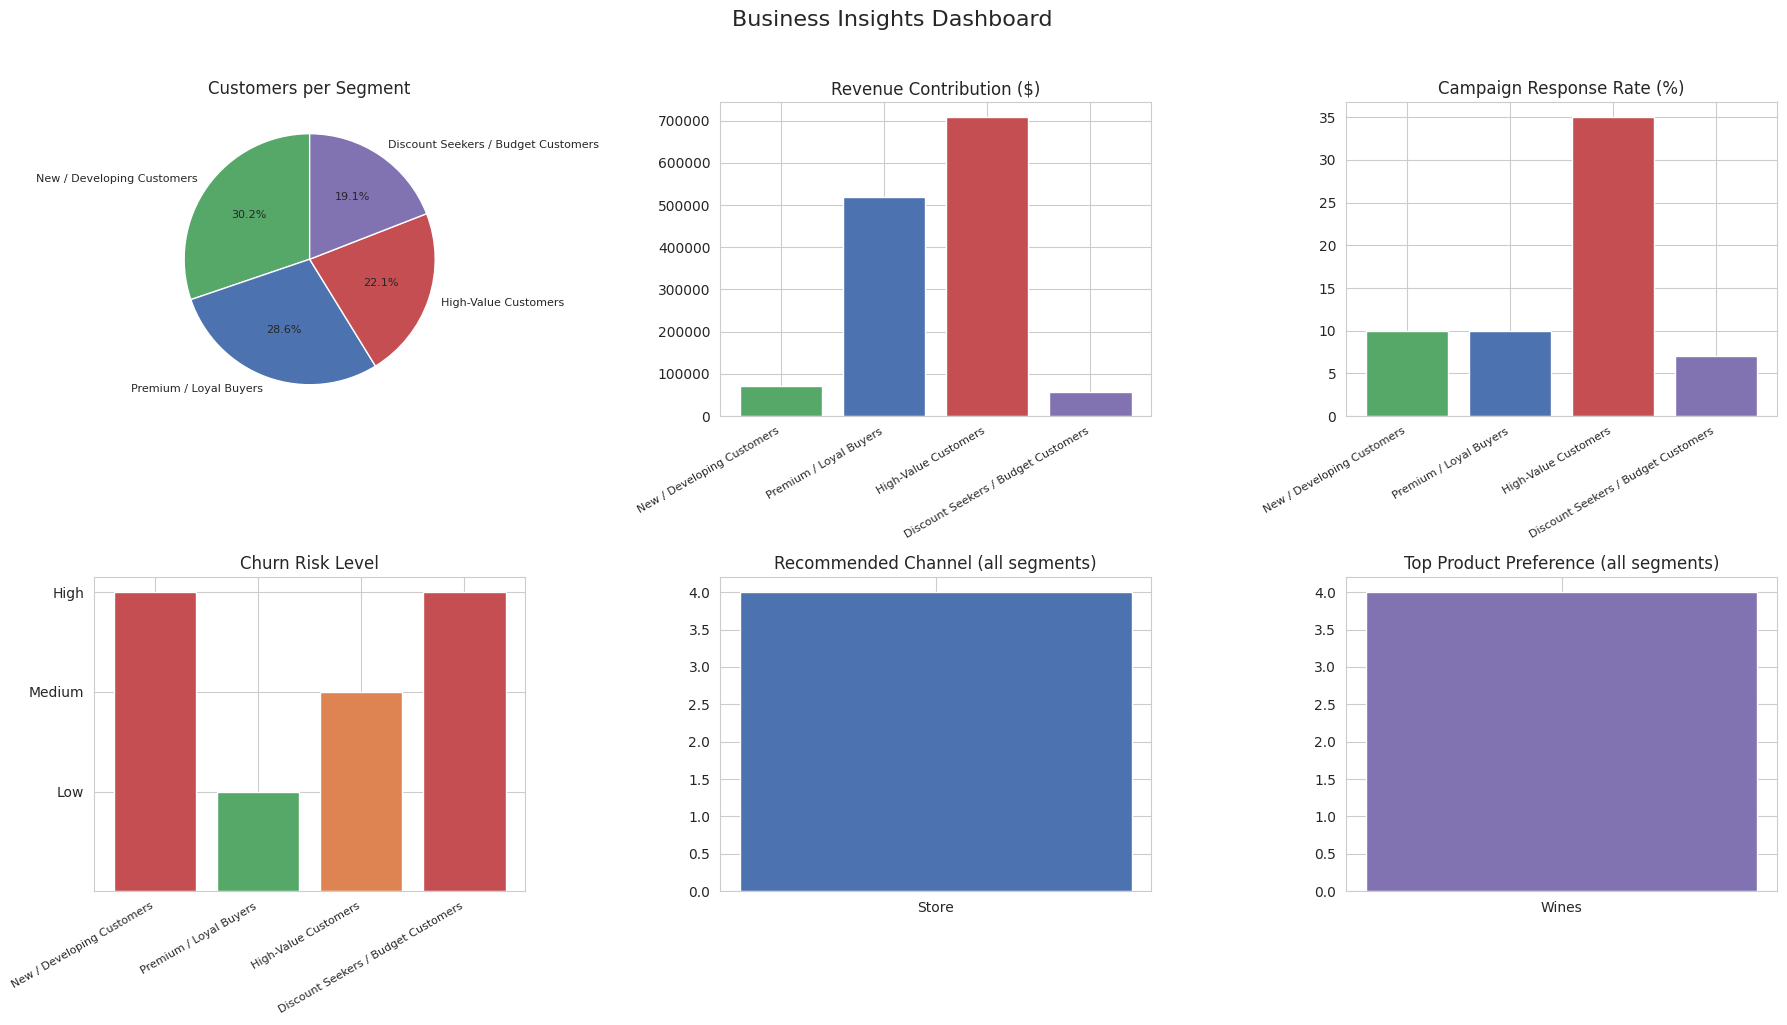

In [9]:
order = metrics.sort_values("Customers", ascending=False)["Segment_Name"].tolist()
colors = [SEGMENT_COLORS[s] for s in order]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sizes = metrics.set_index("Segment_Name").loc[order, "Customers"]
axes[0,0].pie(sizes, labels=order, autopct="%1.1f%%", colors=colors, startangle=90, textprops={"fontsize":8})
axes[0,0].set_title("Customers per Segment")

rev = metrics.set_index("Segment_Name").loc[order, "Revenue_Contribution"]
axes[0,1].bar(range(len(order)), rev.values, color=colors)
axes[0,1].set_xticks(range(len(order))); axes[0,1].set_xticklabels(order, rotation=30, ha="right", fontsize=8)
axes[0,1].set_title("Revenue Contribution ($)")

resp = metrics.set_index("Segment_Name").loc[order, "Campaign_Response_Rate"]*100
axes[0,2].bar(range(len(order)), resp.values, color=colors)
axes[0,2].set_xticks(range(len(order))); axes[0,2].set_xticklabels(order, rotation=30, ha="right", fontsize=8)
axes[0,2].set_title("Campaign Response Rate (%)")

risk_map = {"Low":1,"Medium":2,"High":3}
risk_vals = metrics.set_index("Segment_Name").loc[order,"Churn_Risk_Level"].map(risk_map)
risk_colors = ["#55A868" if v==1 else "#DD8452" if v==2 else "#C44E52" for v in risk_vals]
axes[1,0].bar(range(len(order)), risk_vals.values, color=risk_colors)
axes[1,0].set_xticks(range(len(order))); axes[1,0].set_xticklabels(order, rotation=30, ha="right", fontsize=8)
axes[1,0].set_yticks([1,2,3]); axes[1,0].set_yticklabels(["Low","Medium","High"])
axes[1,0].set_title("Churn Risk Level")

axes[1,1].bar(["Store"], [4], color="#4C72B0")
axes[1,1].set_title("Recommended Channel (all segments)")

axes[1,2].bar(["Wines"], [4], color="#8172B2")
axes[1,2].set_title("Top Product Preference (all segments)")

plt.suptitle("Business Insights Dashboard", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

An interactive HTML version of this dashboard is available at
`04_Dashboard/business_insights_dashboard.html`.

## Task 12 — Management Summary

See the standalone **Executive Management Summary** PDF
(`05_Final_Deliverables/Executive_Management_Summary.pdf`) for the full
3-5 page report covering project overview, key findings, high-value/high-risk
segments, marketing recommendations, revenue opportunities, retention
recommendations, growth opportunities, and conclusion.

In [10]:
FINAL = Path("05_Final_Deliverables")
FINAL.mkdir(exist_ok=True)
df.to_csv(FINAL / "customer_segments_with_strategy.csv", index=False)
print("Final strategy dataset saved:", df.shape)

Final strategy dataset saved: (2237, 67)
